# Telecom Operator Efficiency Analysis: Identifying Underperforming Agents
### Data-driven assessment of call center performance using call metrics, clustering, and statistical hypothesis testing

## Introducción:

CallMeMaybe quiere añadir una función que ayude a supervisores a detectar qué operadores no están rindiendo bien para reducir llamadas perdidas y mejorar la experiencia del cliente. Partimos de registros reales de llamadas (entrantes/salientes, internas/externas) y datos de clientes (plan tarifario). Tras limpiar y agrupar los datos por operador calculamos indicadores clave —llamadas perdidas, tiempo de espera total y por llamada, y volumen de salientes— y definimos umbrales prácticos para marcar ineficiencias. Con ese insumo realizamos un análisis exploratorio, clustering y pruebas estadísticas para identificar patrones replicables y priorizar acciones operativas.

## Objetivo General:

El objetivo general de este proyecto es desarrollar un sistema analítico integral para identificar y clasificar operadores ineficaces en el servicio de telefonía virtual CallMeMaybe, mediante el análisis de métricas clave como llamadas perdidas, tiempos de espera y volumen de llamadas salientes, utilizando técnicas de análisis exploratorio, clustering y pruebas estadísticas para validar hipótesis de negocio y generar recomendaciones accionables que optimicen la gestión de recursos humanos y mejoren la experiencia del cliente.

## Importar librerías

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
#Leer las bases de datos
dt = pd.read_csv('telecom_dataset_new.csv')
cl = pd.read_csv('telecom_clients.csv')

In [3]:
dt.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [4]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


Como se quiere analizar la eficiencia de los operadores, no nos sirven los datos de esta columna que estén ausentes.

In [5]:
cl.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [6]:
cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


## Preprocesamiento de datos:

In [7]:
#Manejar valores ausentes
dt.dropna(inplace = True)
dt.shape

(45670, 9)

Se eliminan todos los valores ausentes de las columnas 'internal' y 'operator_id'.

In [8]:
#Hay valores duplicados?
dt.duplicated().sum()

4179

In [9]:
cl.duplicated().sum()

0

In [10]:
dt = dt.drop_duplicates().reset_index(drop=True)
dt.shape

(41491, 9)

Se eliminan las filas duplicadas.

In [11]:
#Ajustar los tipos de datos
print(np.array_equal(dt['operator_id'], dt['operator_id'].astype('int64')))

True


In [12]:
dt['operator_id'] = dt['operator_id'].astype('int64')
dt['internal'] = dt['internal'].astype('bool')
dt['is_missed_call'] = dt['is_missed_call'].astype('int64')
dt['date'] = pd.to_datetime(dt['date'])
dt['date'] = dt['date'].dt.tz_convert(tz=None)
cl['date_start'] = pd.to_datetime(cl['date_start'])

dt.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 21:00:00,out,True,880022,1,3,0,5
1,166377,2019-08-04 21:00:00,out,True,880020,1,1,0,1
2,166377,2019-08-04 21:00:00,out,True,880020,0,1,10,18
3,166377,2019-08-04 21:00:00,out,False,880022,1,3,0,25
4,166377,2019-08-04 21:00:00,out,False,880020,0,2,3,29


In [13]:
cl.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


## Identificar operadores ineficaces:

In [14]:
#Creamos las columnas con el tiempo de espera y número de llamadas perdidas
dt['waiting_time'] = dt['total_call_duration'] - dt['call_duration']
dt['missed_calls'] = dt['is_missed_call'] * dt['calls_count']

In [15]:
#Agrupar por 'operator_id'
operator_performance_per_direction = dt.groupby(['operator_id','direction']).agg(
    total_calls = ('calls_count','sum'),
    missed_calls = ('missed_calls','sum'),
    total_waiting = ('waiting_time','sum'),
    total_talk = ('call_duration','sum')
).reset_index()
operator_performance_per_direction.head(10)

,operator_id,direction,total_calls,missed_calls,total_waiting,total_talk
0,879896,in,58,0,574,5616
1,879896,out,872,251,11701,58246
2,879898,in,103,0,1673,6351
3,879898,out,7209,2360,102217,251038
4,880020,in,7,0,54,299
5,880020,out,38,22,226,1946
6,880022,in,8,0,112,512
7,880022,out,189,105,3666,14635
8,880026,in,24,0,143,1587
9,880026,out,2208,648,22057,151739


In [16]:
operator_performance = operator_performance_per_direction.groupby('operator_id')[[
    'total_calls','missed_calls','total_waiting','total_talk']].sum().reset_index()
operator_performance.head()

,operator_id,total_calls,missed_calls,total_waiting,total_talk
0,879896,930,251,12275,63862
1,879898,7312,2360,103890,257389
2,880020,45,22,280,2245
3,880022,197,105,3778,15147
4,880026,2232,648,22200,153326


In [17]:
#Valores elevados de llamadas perdidas
np.percentile(operator_performance['missed_calls'], 90)

623.8

In [18]:
#Valores elevados de tiempo de espera
np.percentile(operator_performance['total_waiting'], 90)

29328.299999999996

In [19]:
#Valores reducidos de llamadas salientes
outgoing_calls = operator_performance_per_direction[operator_performance_per_direction['direction']=='out'].reset_index(drop=True)
outgoing_calls.head()

,operator_id,direction,total_calls,missed_calls,total_waiting,total_talk
0,879896,out,872,251,11701,58246
1,879898,out,7209,2360,102217,251038
2,880020,out,38,22,226,1946
3,880022,out,189,105,3666,14635
4,880026,out,2208,648,22057,151739


In [20]:
np.percentile(outgoing_calls['total_calls'], 10)

3.0

In [21]:
#Creamos los indicadores
operator_performance['many_missed_calls'] = np.where(operator_performance['missed_calls'] > 623, 1, 0)
operator_performance['long_waiting_time'] = np.where(operator_performance['total_waiting'] > 29328, 1, 0)
outgoing_calls['low_outgoing_calls'] = np.where(outgoing_calls['total_calls'] <= 3, 1, 0)

In [22]:
total_values = operator_performance.merge(outgoing_calls[['operator_id','low_outgoing_calls']], on='operator_id', how='left')
total_values['low_outgoing_calls'] = total_values['low_outgoing_calls'].fillna(0).astype('int64')
total_values['critical_amount'] = total_values['many_missed_calls']+total_values['long_waiting_time']+total_values['low_outgoing_calls']

In [23]:
#Asignamos nivel de estado crítico del operador
values = {0: 'None', 1: 'Low', 2: 'Medium', 3: 'High'}
total_values['critical_status'] = total_values['critical_amount'].map(values)
total_values.head()

,operator_id,total_calls,missed_calls,total_waiting,total_talk,many_missed_calls,long_waiting_time,low_outgoing_calls,critical_amount,critical_status
0,879896,930,251,12275,63862,0,0,0,0,None
1,879898,7312,2360,103890,257389,1,1,0,2,Medium
2,880020,45,22,280,2245,0,0,0,0,None
3,880022,197,105,3778,15147,0,0,0,0,None
4,880026,2232,648,22200,153326,1,0,0,1,Low


In [24]:
total_values['critical_status'].value_counts()

None      850
Low       152
Medium     90
Name: critical_status, dtype: int64

Hay 850 operadores que funcionan correctamente y 242 operadores con problemas de eficiencia.

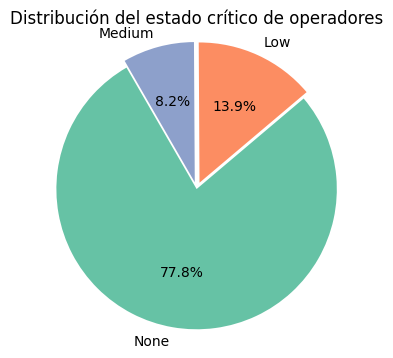

In [25]:
counts = total_values['critical_status'].value_counts().reindex(['None','Low','Medium']).fillna(0)
labels = counts.index
sizes = counts.values
explode = [0.05 if i!='None' else 0 for i in labels]

plt.figure(figsize=(4,4))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=120, explode=explode, colors=plt.cm.Set2.colors)
plt.title('Distribución del estado crítico de operadores')
plt.axis('equal')
plt.show()

El 77.8% de los operadores no presentan problemas. 13.9% tienen un área por mejorar y 8.2% de los operadores tienen un estado crítico elevado con al menos dos áreas con malos resultados.

In [26]:
dt['user_id'].nunique()

290

In [27]:
dt['operator_id'].nunique()

1092

In [28]:
cl.groupby(['tariff_plan'])['user_id'].nunique()

tariff_plan
A     76
B    261
C    395
Name: user_id, dtype: int64

La lista de usuarios con planes vigentes es bastante más grande que la de clientes que realizaron llamadas.

In [29]:
#Agrupar operadores y planes para ver qué grupo está siendo más afectado
dt_2 = dt[['user_id','operator_id']].merge(cl[['user_id','tariff_plan']])
dt_2.head()

,user_id,operator_id,tariff_plan
0,166377,880022,B
1,166377,880020,B
2,166377,880020,B
3,166377,880022,B
4,166377,880020,B


In [30]:
total_values_simplified = total_values[['operator_id','critical_status']]
total_values_simplified = total_values_simplified.merge(dt_2[['operator_id','tariff_plan']], on='operator_id', how='left')
status_by_tariff_plan = total_values_simplified.groupby(['tariff_plan','critical_status']).count().reset_index()
status_by_tariff_plan

,tariff_plan,critical_status,operator_id
0,A,Low,711
1,A,Medium,3010
2,A,None,8492
3,B,Low,1488
4,B,Medium,1679
5,B,None,11300
6,C,Low,2150
7,C,Medium,2602
8,C,None,10059


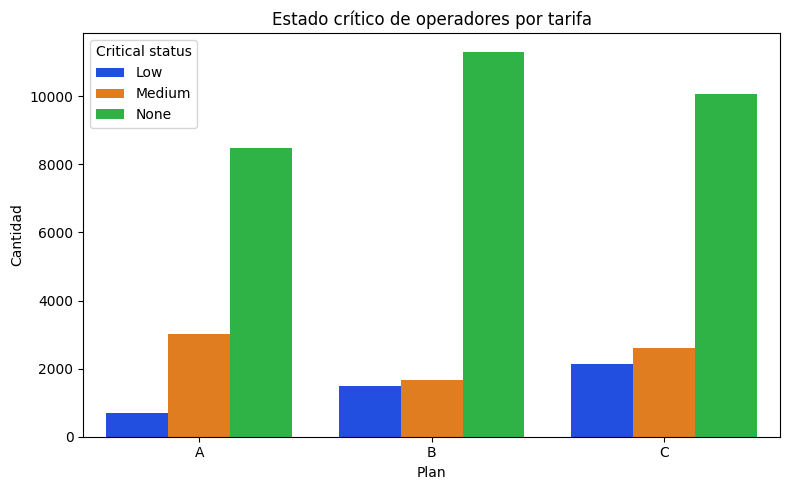

In [31]:
plt.figure(figsize=(8,5))
plt.title('Estado crítico de operadores por tarifa')
ax = sns.barplot(
    data=status_by_tariff_plan,
    x='tariff_plan',
    y='operator_id',
    hue='critical_status',
    palette='bright',
    ci=None
)
ax.set_xlabel('Plan')
ax.set_ylabel('Cantidad')
plt.legend(title='Critical status')
plt.tight_layout()
plt.show()

Los tres grupos de planes muestran resultados similares en cantidad bruta de operadores ineficientes; el grupo de tarifa B parece tener una proporción menor comparándolo con los operadores que funcionan correctamente.

## Comprobación con machine learning:

In [32]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [33]:
#Estandarizar los datos
values = total_values[['total_calls','missed_calls','total_waiting','total_talk','critical_amount']]
values_log = np.log1p(values) #Para mitigar valores atípicos
sc = RobustScaler()
x_sc = sc.fit_transform(values_log)

In [34]:
#Modelo DBSCAN
db = DBSCAN(eps=0.4, min_samples=5, metric='euclidean')
labels_db = db.fit_predict(x_sc)
total_values['cluster_db'] = labels_db
total_values['db_outlier'] = (total_values['cluster_db'] == -1).astype(int) #Valores atípicos
counts = total_values['cluster_db'].value_counts().sort_index()
counts

-1     14
 0    845
 1     88
 2     36
 3    109
Name: cluster_db, dtype: int64

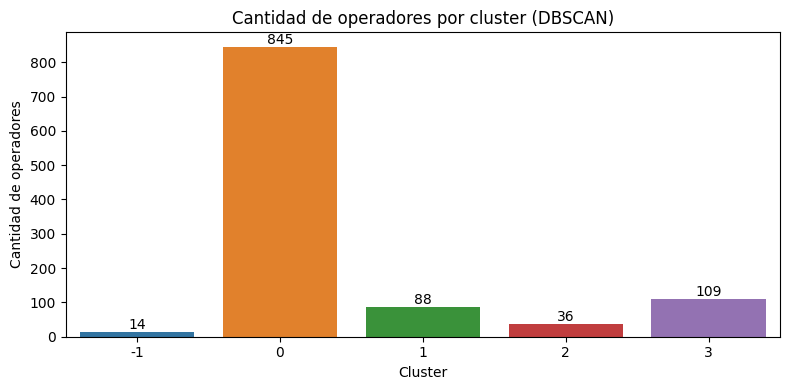

In [35]:
plt.figure(figsize=(8,4))
sns.barplot(x=counts.index.astype(str), y=counts.values, palette='tab10')
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01, str(v), ha='center')
plt.title('Cantidad de operadores por cluster (DBSCAN)')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de operadores')
plt.tight_layout()
plt.show()

In [36]:
total_values.groupby('cluster_db').mean().drop('operator_id', axis=1).round(2)

,total_calls,missed_calls,total_waiting,total_talk,many_missed_calls,long_waiting_time,low_outgoing_calls,critical_amount,db_outlier
cluster_db,,,,,,,,,
-1,9069.86,3403.43,213427.29,592033.29,0.14,0.43,0.21,0.79,1.0
0,246.73,71.66,4003.51,20209.70,0.00,0.00,0.00,0.00,0.0
1,3393.64,1612.15,62516.24,146598.98,1.00,1.00,0.00,2.00,0.0
2,1871.83,614.83,29746.92,101046.47,0.56,0.44,0.00,1.00,0.0
3,5.49,1.02,98.83,374.90,0.00,0.00,1.00,1.00,0.0


Como se puede ver en los clusters creados por el modelo, el grupo -1 corresponde a valores atípicos, el grupo 0 son los operadores eficientes, el grupo 1 son los más ineficientes por tener diversos problemas. El clúster 2 tienen problemas de llamadas perdidas o largos tiempos de espera y los del 3 tienen pocas llamadas salientes.  Estas cantidades son muy parecidas a las halladas anteriormente al establecer el 'critical_status' a cada operador.

## Hipótesis Estadística

In [37]:
from scipy import stats as st

### Hipótesis 1: Entre mayor sea el tiempo de espera, mayores serán las llamadas perdidas de los operadores.
H0: No hay correlación positiva entre missed_calls y total_waiting por operador

H1: Existe correlación positiva entre missed_calls y total_waiting por operador

In [38]:
#Test de correlación de Spearman (trabaja con datos sesgados, no asume normalidad en los datos)

alpha = 0.05 #Nivel de significancia
h1 = st.spearmanr(operator_performance['missed_calls'], operator_performance['total_waiting'])

if h1.pvalue < alpha:
    print('Valor estadístico: ', h1.statistic.round(3))
    print('P-Value: ', h1.pvalue)
    print('Se rechaza la hipótesis nula H0')
else:
    print('Valor estadístico: ', h1.statistic.round(3))
    print('P-Value: ', h1.pvalue)
    print('No hay suficiente evidencia estadística para rechazar la hipótesis nula')

Valor estadístico:  0.886
P-Value:  0.0
Se rechaza la hipótesis nula H0


Si hay una correlación positiva entre el tiempo de espera y las llamadas perdidas. Por lo tanto, es importante minimizar los tiempos de espera de los operadores para mitigar el número de llamadas perdidas.

### Hipótesis 2: Hay diferencias en la eficiencia de los operadores según el plan tarifario
H0: La distribución del critical_status no difiere entre planes tarifarios A, B, C

H1: Al menos un plan tiene distribución distinta de critical_status

In [39]:
from statsmodels.stats.proportion import proportions_ztest

In [40]:
tvs = total_values_simplified.copy()
tvs['is_problem'] = (tvs['critical_status'] != 'None').astype(int)

tvs_grouped = tvs.groupby('tariff_plan').agg(
    problems=('is_problem','sum'),
    total=('operator_id','count')
).reset_index()
tvs_grouped

,tariff_plan,problems,total
0,A,3721,12213
1,B,3167,14467
2,C,4752,14811


In [41]:
#Ztest para cada par de planes

pairs = [('A','B'), ('A','C'), ('B','C')]
alpha = 0.05 #Nivel de significancia
m = len(pairs)
results = []

for p1, p2 in pairs:
    row1 = tvs_grouped[tvs_grouped['tariff_plan']==p1].iloc[0]
    row2 = tvs_grouped[tvs_grouped['tariff_plan']==p2].iloc[0]
    count = np.array([row1['problems'], row2['problems']])
    nobs = np.array([row1['total'], row2['total']])

    zstat, pval = proportions_ztest(count, nobs)
    pval_bonf = min(pval * m, 1.0)
    results.append({
        'plan_1': p1,
        'plan_2': p2,
        'prop_1': row1['problems']/row1['total'],
        'prop_2': row2['problems']/row2['total'],
        'z': zstat,
        'p_raw': pval,
        'p_bonf': pval_bonf
    })

df_result = pd.DataFrame(results)
df_result

,plan_1,plan_2,prop_1,prop_2,z,p_raw,p_bonf
0,A,B,0.304675,0.218912,15.947904,2.946216e-57,8.838649e-57
1,A,C,0.304675,0.320843,-2.851101,4.356810e-03,1.307043e-02
2,B,C,0.218912,0.320843,-19.630490,8.489281e-86,2.546784e-85


In [42]:
for i in df_result.iterrows():
    row = i[1]
    print(f"Planes: {row['plan_1']} y {row['plan_2']}")
    print(f"Proporción de operadores ineficientes: {row['prop_1']:.3f} y {row['prop_2']:.3f}")
    
    if row['p_bonf'] < alpha:
        print('Se rechaza la hipótesis nula H0, las proporciones de los planes difieren significativamente')
        print('')
    else:
        print('No hay suficiente evidencia estadística para rechazar la hipótesis nula')
        print('')

Planes: A y B
Proporción de operadores ineficientes: 0.305 y 0.219
Se rechaza la hipótesis nula H0, las proporciones de los planes difieren significativamente

Planes: A y C
Proporción de operadores ineficientes: 0.305 y 0.321
Se rechaza la hipótesis nula H0, las proporciones de los planes difieren significativamente

Planes: B y C
Proporción de operadores ineficientes: 0.219 y 0.321
Se rechaza la hipótesis nula H0, las proporciones de los planes difieren significativamente



Según esta prueba estadística, los planes A y C están siendo más afectados que los clientes del plan B. Anteriormente, se graficó la cantidad de operadores críticos por plan y no se encontraron diferencias significativas a simple vista, sin embargo, ahora se confirma que los operadores si han afectado de forma diferente cada tipo de plan.
A partir de esto, se recomienda priorizar investigación en operadores bajo el plan B, ya que tienen menor proporción de ineficiencia.

### Hipótesis 3: Las llamadas internas y externas tienen tiempos de espera distintos
H0: La mediana del waiting_time por llamada es igual entre llamadas internas y externas

H1: La mediana difiere entre llamadas internas y externas

In [43]:
operator_performance_in_and_out = dt.groupby(['operator_id','internal']).agg(
    total_calls = ('calls_count','sum'),
    missed_calls = ('missed_calls','sum'),
    total_waiting = ('waiting_time','sum'),
    total_talk = ('call_duration','sum')
).reset_index()

op = operator_performance_in_and_out
op = op[op['total_calls'] > 0]
op['waiting_per_call'] = round(op['total_waiting'] / op['total_calls'],2)
op.head()

,operator_id,internal,total_calls,missed_calls,total_waiting,total_talk,waiting_per_call
0,879896,False,874,220,11983,62588,13.71
1,879896,True,56,31,292,1274,5.21
2,879898,False,7294,2345,103829,257351,14.23
3,879898,True,18,15,61,38,3.39
4,880020,False,41,19,271,2235,6.61


In [44]:
group_int = op[op['internal'] == True]['waiting_per_call'].values
group_ext = op[op['internal'] == False]['waiting_per_call'].values

median_int = np.median(group_int)
median_ext = np.median(group_ext)

print(median_int)
print(median_ext)

6.13
16.71


Acá se puede ver que la mediana del tiempo de espera por llamada es mayor en las externas que en las llamadas internas.

In [45]:
#Prueba de normalidad Shapiro-Wilk
alpha = 0.05
shapiro_int = st.shapiro(group_int)
shapiro_ext = st.shapiro(group_ext)

print('Llamadas internas:')
if shapiro_int.pvalue < alpha:
    print('Se rechaza la hipótesis nula, la distribución no es normal')
    print('')
else:
    print('No hay suficiente evidencia estadística para rechazar la hipótesis nula, la distribución parece normal')
    print('')

print('Llamadas externas:')
if shapiro_ext.pvalue < alpha:
    print('Se rechaza la hipótesis nula, la distribución no es normal')
else:
    print('No hay suficiente evidencia estadística para rechazar la hipótesis nula, la distribución parece normal')

Llamadas internas:
Se rechaza la hipótesis nula, la distribución no es normal

Llamadas externas:
Se rechaza la hipótesis nula, la distribución no es normal


In [46]:
#Prueba no paramétrica de Wilcoxon-Mann-Whitney:
alpha = 0.05
h3 = st.mannwhitneyu(group_int, group_ext)

print(f'Valor estadístico: {h3.statistic:}')
print(f'P-value: {h3.pvalue:}')
print('')
if h3.pvalue < alpha:
    print('Se rechaza la hipótesis nula, existen diferencias significativas entre las distribuciones de los dos grupos')
else:
    print('No hay suficiente evidencia estadística para rechazar la hipótesis nula')

Valor estadístico: 101066.5
P-value: 9.581028771062987e-108

Se rechaza la hipótesis nula, existen diferencias significativas entre las distribuciones de los dos grupos


Se confirma que hay diferencias significativas entre las medias de tiempos de espera en llamadas externas. Por lo tanto es necesario mejorar el rendimiento de los operadores en esta área.

## Conclusiones
Tras limpiar y preparar los datos se trabajó con 41,491 registros útiles y 1,092 operadores activos. Se calcularon indicadores por operador: llamadas totales, llamadas perdidas, tiempo total de espera y tiempo de espera por llamada. Con esos indicadores se identificaron 242 operadores con algún grado de ineficiencia según umbrales basados en percentiles.

El agrupamiento con DBSCAN sobre las métricas transformadas y escaladas produjo cinco segmentos claros: un pequeño grupo de outliers, un grupo numeroso con desempeño esperado, un grupo con problemas críticos, otro con tiempos de espera elevados y otro con bajo volumen de llamadas salientes. Esto permite priorizar acciones: auditar primero los outliers y el grupo crítico, luego tratar los grupos con problemas específicos.

Los tests estadísticos confirman y fortalecen los hallazgos del análisis exploratorio y del clustering. Hay una asociación fuerte entre mayores tiempos de espera acumulados y más llamadas perdidas por operador, lo que sugiere que reducir el tiempo que esperan las llamadas debería disminuir las perdidas. Las proporciones de operadores ineficientes difieren entre planes tarifarios: aproximadamente 30.5% en el plan A, 21.9% en el plan B y 32.1% en el plan C, y estas diferencias resultaron estadísticamente significativas en las comparaciones por pares. La mediana del tiempo de espera por llamada es de alrededor de 6 segundos para llamadas internas y de alrededor de 17 segundos para llamadas externas, mostrando que las llamadas externas enfrentan mayores tiempos de espera.

## Recomendaciones
. Priorizar la reducción del tiempo de espera por llamada para reducir las llamadas perdidas; acciones prácticas: optimizar enrutamiento, ajustar dotación de personal en horarios pico y revisar acuerdos de nivel de servicio.

. Auditar los outliers y los operadores del segmento más crítico para identificar causas puntuales (configuración, picos de carga, falta de formación) y aplicar medidas correctivas rápidas.

. Investigar las diferencias entre planes tarifarios controlando variables como volumen de llamadas por cliente y antigüedad, antes de tomar decisiones comerciales o de asignación de recursos.

. Implantar monitoreo continuo con los indicadores definidos y repetir el clustering periódicamente para detectar degradaciones y validar el impacto de las intervenciones.

. Complementar con modelos ajustados (por ejemplo, regresión logística) que permitan confirmar qué factores realmente predicen ineficiencia una vez controladas las covariables, y reportar intervalos de confianza y tamaños de efecto para guiar la toma de decisiones.

In [47]:
#Recuperar datos para dashboards
df = dt[dt['calls_count'] > 0].loc[:, [
    'date','direction','internal','calls_count','call_duration','total_call_duration'
]].copy()

df['duration_per_call'] = df['call_duration'] / df['calls_count']
df['total_duration_per_call'] = df['total_call_duration'] / df['calls_count']

df_tableau = df[['date','direction','internal','calls_count','duration_per_call','total_duration_per_call']]
df_tableau.to_csv('dash_data_tableau.csv', index=False, sep=';', decimal=',')